In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv("mymoviedb.csv",engine="python")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
# Data Pre-processing

# changed the data types of data accordingly
df['Release_Date']= pd.to_datetime(df['Release_Date'],  format='%Y-%m-%d', errors='coerce')
print(df['Release_Date'].dtypes)

df.columns = df.columns.str.strip()
df['Vote_Count']= pd.to_numeric(df['Vote_Count'] ,errors='coerce')
print(df['Vote_Count'].dtypes)

df['Vote_Average']= pd.to_numeric(df['Vote_Average'] ,errors='coerce')
print(df['Vote_Average'].dtypes)

df['Release_Date']= df['Release_Date'].dt.year
print(df['Release_Date'].dtypes)


datetime64[ns]
float64
float64
float64


In [4]:
# dropped columns
df = df.drop(['Overview','Original_Language','Poster_Url'], axis=1)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,6.3,Thriller
3,2021.0,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


In [6]:
# Data Cleaning

def categorize_col(df, col, labels):
    df[col] = pd.to_numeric(df[col],errors='coerce')

    # setting the edges
    edges = [
        df[col].min(),
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].max()
    ]
    edges = sorted(set(edges))

    df[col] = pd.cut(df[col], edges, labels=labels,)
    return df


labels = ['not_popular', 'below_avg', 'average', 'popular']
categorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [7]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,below_avg,Thriller
3,2021.0,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War"


In [8]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [9]:
# check for duplicated rows
df.duplicated().sum()

np.int64(8)

In [10]:
# check for null 
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [11]:
# split the strings into lists
df['Genre'] = df['Genre'].str.split(', ')
# explode -  converts list items into separate rows
df = df.explode('Genre').reset_index(drop=True)
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151.0,popular,Crime
4,2022.0,The Batman,3827.658,1151.0,popular,Mystery


In [12]:
# Categorize the genre
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [13]:
#df.info()
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151.0,popular,Crime
4,2022.0,The Batman,3827.658,1151.0,popular,Mystery


Data Visulaization

In [15]:
 # Q1: What is the most frequent genre in the dataset?
df['Genre'].describe()


count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

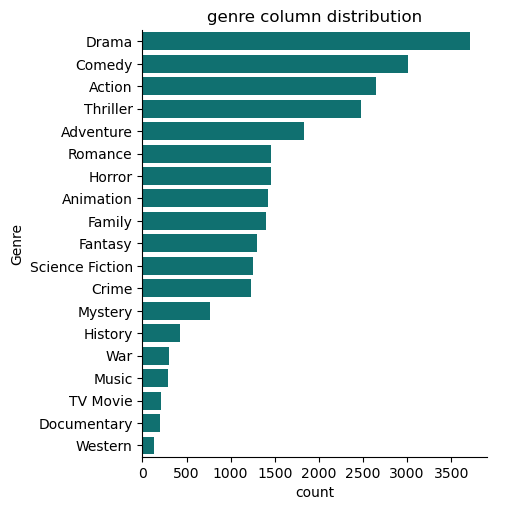

In [16]:
sns.catplot(y = 'Genre', data = df, kind = 'count',
order = df['Genre'].value_counts().index,
color = 'teal')
plt.title('genre column distribution')
plt.show()


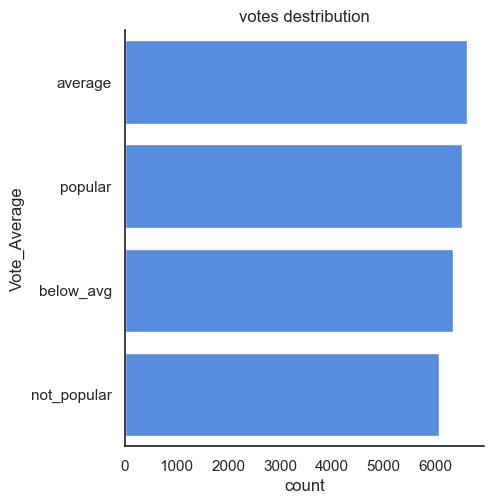

In [17]:
# Q2: What genres has highest votes ?
sns.set_theme(style='white')
sns.catplot(y = 'Vote_Average', data = df, kind = 'count',
order = df['Vote_Average'].value_counts().index,
color = '#4287f5')
plt.title('votes destribution')
plt.show()

In [18]:
# Q3:  What movie got the highest popularity ? what's its genre ?
df[df['Popularity'] == df['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction


In [19]:
# Q4: What movie got the lowest popularity? what's its genre?
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,Music
25546,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,Drama
25547,2021.0,The United States vs. Billie Holiday,13.354,152.0,average,History
25548,1984.0,Threads,13.354,186.0,popular,War
25549,1984.0,Threads,13.354,186.0,popular,Drama
25550,1984.0,Threads,13.354,186.0,popular,Science Fiction


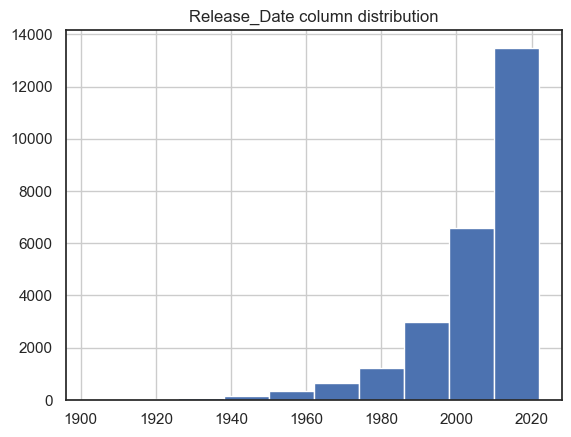

In [20]:
# Q5: Which year has the most filmed movies?
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()



Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than
14% of the times among 19 other genres.

Q2: What genres has highest votes ?
we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
highest popularity among fans by being having more than 18.5% of movies popularities.

Q3: What movie got the highest popularity ? what's its genre ?
Spider-Man: No Way Home has the highest popularity rate in our dataset and it has
genres of Action , Adventure and Sience Fiction .

Q4: What movie got the lowest popularity ? what's its genre ?
The united states, thread' has the highest lowest rate in our dataset
and it has genres of music , drama , 'war', 'sci-fi' and history`.

Q5: Which year has the most filmed movies?
year 2020 has the highest filmming rate in our dataset.